# Lab — Statistical Testing with SciPy (Starter)

**Estimated time:** ~30 minutes  
**Tools:** Python 3, Jupyter Notebook, SciPy, Pandas, NumPy, Matplotlib

You will:
- Compute **descriptive statistics**
- Define a **hypothesis** (H₀ / H₁)
- Run a **hypothesis test** with SciPy
- **Visualise** distributions to support interpretation
- Summarise conclusions in **markdown**


## 1) Setup & Environment Check

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

try:
    import scipy
    from scipy import stats
    print("SciPy version:", scipy.__version__)
except ImportError:
    raise ImportError(
        "SciPy is not installed. Install it with:\n"
        "  - pip install scipy\n"
        "  - conda install scipy"
    )


SciPy version: 1.10.1


## 2) Load the Dataset

In [15]:
# TODO: Load dataset
# df = pd.read_csv("data/raw/experiment_results.csv")

# YOUR CODE HERE

df = pd.read_csv(Path("..") / "data" / "experiment_results.csv")
df.head()


,participant_id,group,time_on_task_seconds
0,C001,control,323.7
1,C002,control,263.2
2,C003,control,343.8
3,C004,control,352.3
4,C005,control,222.2


In [7]:
# TODO: Preview + basic checks
# df.head()
# df.info()

# YOUR CODE HERE

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   participant_id        120 non-null    object 
 1   group                 120 non-null    object 
 2   time_on_task_seconds  120 non-null    float64
dtypes: float64(1), object(2)
memory usage: 2.9+ KB


## 3) Compute Descriptive Statistics

In [8]:
# TODO: Overall descriptive stats
# df["time_on_task_seconds"].describe()

# YOUR CODE HERE
df["time_on_task_seconds"].describe()

count    120.000000
mean     317.285000
std       35.131957
min      222.200000
25%      290.350000
50%      317.650000
75%      343.500000
max      406.400000
Name: time_on_task_seconds, dtype: float64

In [9]:
# TODO: Grouped descriptive stats
# df.groupby("group")["time_on_task_seconds"].agg(["count", "mean", "std", "min", "max"])

# YOUR CODE HERE
df.groupby("group")["time_on_task_seconds"].agg(["count", "mean", "std", "min", "max"])


,count,mean,std,min,max
group,,,,,
control,60,312.938333,35.354745,222.2,406.4
treatment,60,321.631667,34.656066,252.3,402.1


## 4) Define Your Hypothesis

### Hypothesis

- **H₀ (null):** The mean value is the same for both control and treatment groups. 
- **H₁ (alternative):** The mean value differs between control and treatment groups.  
- **Significance level (α):** 0.05  


## 5) Perform a Hypothesis Test (SciPy)

In [13]:
# TODO: Split into two arrays
# control = df.loc[df["group"] == "control", "time_on_task_seconds"].to_numpy()
# treatment = df.loc[df["group"] == "treatment", "time_on_task_seconds"].to_numpy()

# YOUR CODE HERE
control = df.loc[df["group"] == "control", "time_on_task_seconds"].to_numpy()
treatment = df.loc[df["group"] == "treatment", "time_on_task_seconds"].to_numpy()
print(control)
print()
print(treatment)

[323.7 263.2 343.8 352.3 222.2 251.4 315.8 295.8 309.2 271.6 349.6 345.
 313.  360.7 331.  271.3 326.6 266.9 349.5 307.8 301.7 279.4 365.  303.
 290.7 294.2 334.  326.4 328.6 329.4 406.4 291.7 286.9 273.4 337.7 360.8
 304.9 272.2 272.9 339.3 343.4 334.4 280.1 320.4 315.3 319.8 349.2 320.1
 340.6 313.  323.  338.4 244.4 295.6 288.8 281.3 297.6 377.3 271.  353.6]

[254.3 314.9 337.3 356.4 362.  365.7 314.3 309.2 368.6 321.4 272.6 279.
 288.6 352.4 336.4 361.1 310.8 337.1 358.2 316.1 350.6 300.2 313.7 312.8
 276.2 351.9 308.9 330.6 351.6 350.1 359.9 325.6 311.  326.4 254.1 264.9
 270.5 285.1 348.  289.3 313.  388.5 314.  363.2 288.  320.8 287.2 314.7
 367.8 252.3 349.5 340.7 303.3 264.9 333.2 306.2 340.5 331.  402.1 319.2]


In [14]:
# TODO: Run Welch's t-test (recommended when variances may differ)
# t_stat, p_value = stats.ttest_ind(treatment, control, equal_var=False)
# print("t statistic:", t_stat)
# print("p-value:", p_value)

# YOUR CODE HERE
t_stat, p_value = stats.ttest_ind(treatment, control, equal_var=False)
print("t statistic:", t_stat)
print("p-value:", p_value)


t statistic: 1.3601607062059062
p-value: 0.17637296469048666


## 6) Visualise the Data

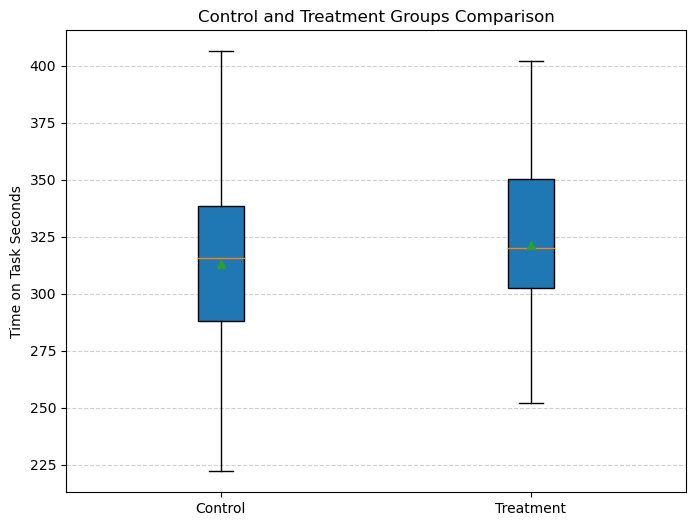

In [17]:
# TODO: Create at least ONE plot (boxplot or histogram) to compare groups.
# Tip: A boxplot is often a quick, clear comparison.

# YOUR CODE HERE

plt.figure(figsize=(8, 6))

plt.boxplot(
    [control, treatment],
    labels=["Control", "Treatment"],
    patch_artist=True,
    showmeans=True
)

plt.ylabel("Time on Task Seconds")
plt.title("Control and Treatment Groups Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


## 7) Interpret and Document Results

### Results & Interpretation

- **Test used:** A Welch's t-test was used to perform the hypothesis test 
- **t statistic:** 1.3601607062059062  
- **p-value:** 0.17637296469048666 
- **Decision (α = 0.05):** We do not reject the null hypothesis, which states that the mean value is the same for both control and treatment groups.  
- **Plain-language conclusion:** The results show that treatment group spends a little more time on average, but there is no significant time difference between control and treatment groups.  

**Assumptions / limitations:**  

-We assume that data sets are independent and also normal distributions.

-The test is only limited to testing whether the average times between control and treatment are the same. Other distributional differences are not tested.

-The test is not meant to conclude that treatment has no effect. The test only posits that there is no statistical evidence to conlude that the average times on task are different.
